# DCT Probe Analysis v2 — Publication Figures

Publication-ready version of `dct_probe_analysis_v2.ipynb`. All figures saved as SVG + PDF vector formats with a clean academic style.

In [1]:
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
from scipy import stats as scipy_stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from IPython.display import display

In [2]:
import os
repo_root = Path.cwd()
while not (repo_root / "dct_probes").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
os.chdir(repo_root)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/FletcAW1/Documents/repos/personal/SPAR-causal-probes


In [3]:
EXPERIMENT_NAME = "llama-3.1-8b-1024factors-categorical"
experiment_dir = Path(f"dct_probes/experiments/{EXPERIMENT_NAME}")
data_dir = Path("dct_probes/data")

with open(experiment_dir / "vectors" / "dct_run_config.json") as f:
    run_cfg = json.load(f)

MODEL_NAME = run_cfg["MODEL_NAME"]
PROBE_LAYER = run_cfg["PROBE_LAYER"]
SYSTEM_PROMPT = run_cfg.get("SYSTEM_PROMPT", "You are a helpful assistant")
TOKEN_IDXS_START = run_cfg.get("TOKEN_IDXS_START", -3)
TOKEN_IDXS_STOP = run_cfg.get("TOKEN_IDXS_STOP", None)
INPUT_SCALE = run_cfg.get("INPUT_SCALE", None)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Device:      {device}")
print(f"Experiment:  {EXPERIMENT_NAME}")
print(f"Model:       {MODEL_NAME}")
print(f"Probe layer: {PROBE_LAYER}")

Device:      mps
Experiment:  llama-3.1-8b-1024factors-categorical
Model:       meta-llama/Llama-3.1-8B-Instruct
Probe layer: 10


## Publication Style Configuration

In [4]:
# Color palette — blue/orange anchored scheme inspired by reference plots
COLORS = {
    "mm":            "#2563EB",
    "lr":            "#D97706",
    "dct":           "#0891B2",
    "ensemble_mean": "#16A34A",
    "ensemble_max":  "#DC2626",
    "train":         "#2563EB",
    "test":          "#16A34A",
    "random":        "#9CA3AF",
}

DCT_COLORS = [
    "#0e7490", "#0891b2", "#06b6d4", "#22d3ee", "#67e8f9",
    "#1d4ed8", "#2563eb", "#3b82f6", "#60a5fa", "#93c5fd",
]

# Publication rcParams — serif font, clean academic style
plt.rcParams.update({
    # Font
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "Palatino", "Georgia", "DejaVu Serif"],
    "mathtext.fontset":    "stix",
    "font.size":           10,
    "axes.labelsize":      11,
    "axes.titlesize":      12,
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "legend.fontsize":     9,
    "legend.title_fontsize": 9,
    # Legend style
    "legend.framealpha":   0.95,
    "legend.edgecolor":    "#CCCCCC",
    "legend.borderpad":    0.5,
    "legend.handlelength": 1.8,
    # Output quality
    "figure.dpi":          150,
    "savefig.dpi":         300,
    # Axes
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.linewidth":      0.8,
    "axes.labelpad":       5,
    "axes.titlelocation":  "center",
    "axes.titlepad":       10,
    "axes.axisbelow":      True,
    # Ticks
    "xtick.major.width":   0.8,
    "ytick.major.width":   0.8,
    "xtick.major.size":    4,
    "ytick.major.size":    4,
    "xtick.direction":     "out",
    "ytick.direction":     "out",
    # Lines
    "lines.linewidth":     1.5,
    "lines.markersize":    5,
    # Misc
    "axes.grid":           False,
    "figure.autolayout":   False,
})

print("Publication style configured (serif font, academic aesthetic).")

Publication style configured (serif font, academic aesthetic).


In [5]:
IMAGE_DIR = Path("dct_probes/images") / EXPERIMENT_NAME / "pub"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig: plt.Figure, name: str) -> None:
    """Save figure as SVG and PDF for publication."""
    for fmt in ["svg", "pdf"]:
        path = IMAGE_DIR / f"{name}.{fmt}"
        fig.savefig(str(path), format=fmt, bbox_inches="tight")
        print(f"Saved: {path}")

print(f"Image output dir: {IMAGE_DIR}")

Image output dir: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub


## Load DCT Vectors & Judge Scores

In [6]:
data = torch.load(experiment_dir / "vectors" / "dct_vectors.pt", weights_only=True, map_location="cpu")
V = data["V"].to(dtype=torch.float32)
print(f"V shape: {V.shape}  (d_model x num_factors)")

df_judge = pd.read_json(experiment_dir / "results" / "judge_results.jsonl", lines=True)

if "judge_category" in df_judge.columns:
    def lying_score(cats):
        cw  = (cats == "CONFIDENTLY_WRONG").mean()
        ca  = (cats == "CORRECT").mean()
        hw  = (cats == "HEDGED_WRONG").mean()
        gc_ = (cats == "GARBAGE").mean()
        ref = (cats == "REFUSAL").mean()
        return cw / (cw + gc_ + ref + ca + hw + 1e-8)

    steered = df_judge[df_judge["factor_idx"] >= 0].copy()
    mean_deltas = steered.groupby("factor_idx")["judge_category"].apply(lying_score).sort_values(ascending=False)

    baseline_cats = df_judge[df_judge["factor_idx"] == -1]["judge_category"].value_counts(normalize=True)
    print("Baseline category distribution:")
    print(baseline_cats.to_string())
else:
    df_judge = df_judge.dropna(subset=["judge_score"])
    df_judge["judge_score"] = df_judge["judge_score"].astype(int)

    baseline = df_judge[df_judge["factor_idx"] == -1].set_index("prompt_id")["judge_score"]
    steered = df_judge[df_judge["factor_idx"] >= 0].copy()
    steered = steered.merge(baseline.rename("baseline_score"), on="prompt_id")
    steered["delta"] = steered["judge_score"] - steered["baseline_score"]
    mean_deltas = steered.groupby("factor_idx")["delta"].mean().sort_values(ascending=False)

    print(f"Mean baseline deception score: {baseline.mean():.1f}")

print(f"\nNumber of DCT factors: {len(mean_deltas)}")
print("\nTop 10 factor indices:")
print(mean_deltas.head(10).to_string())

V shape: torch.Size([4096, 1024])  (d_model x num_factors)
Baseline category distribution:
judge_category
GARBAGE    0.5
CORRECT    0.5

Number of DCT factors: 1024

Top 10 factor indices:
factor_idx
246    0.500000
59     0.400000
953    0.400000
472    0.400000
619    0.400000
155    0.333333
424    0.333333
895    0.333333
698    0.300000
288    0.300000


### Judge Category Distribution

Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/judge_category_distribution.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/judge_category_distribution.pdf


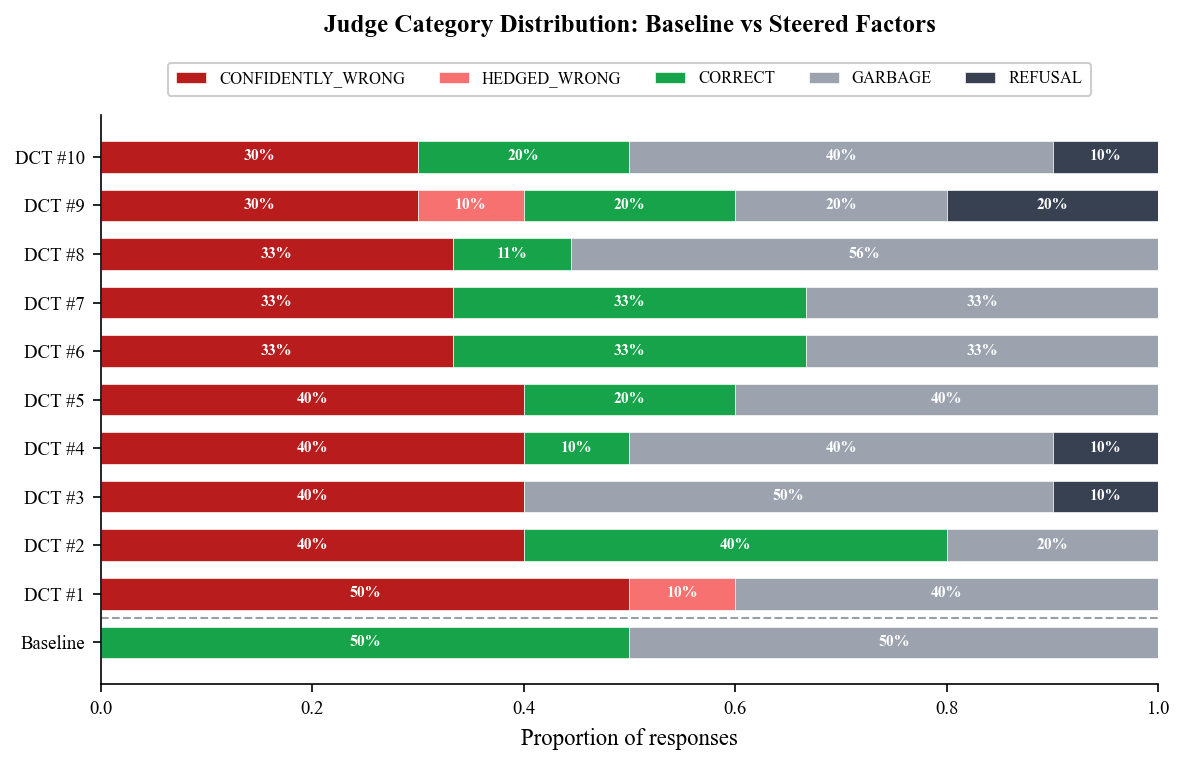

In [7]:
if "judge_category" in df_judge.columns:
    top_indices_for_butterfly = mean_deltas.index.tolist()[:10]
    factors_to_show = [-1] + top_indices_for_butterfly
    factor_labels = ["Baseline"] + [f"DCT #{i+1}" for i in range(len(top_indices_for_butterfly))]

    cat_order = ["CONFIDENTLY_WRONG", "HEDGED_WRONG", "CORRECT", "GARBAGE", "REFUSAL"]
    cat_colors = {
        "CONFIDENTLY_WRONG": "#B91C1C",
        "HEDGED_WRONG":      "#F87171",
        "CORRECT":           "#16A34A",
        "GARBAGE":           "#9CA3AF",
        "REFUSAL":           "#374151",
    }

    rows = []
    for idx in factors_to_show:
        cats = df_judge[df_judge["factor_idx"] == idx]["judge_category"]
        fracs = cats.value_counts(normalize=True) if len(cats) > 0 else pd.Series(dtype=float)
        rows.append({c: float(fracs.get(c, 0.0)) for c in cat_order})

    fig, ax = plt.subplots(figsize=(8, 5.2))
    y = np.arange(len(factors_to_show))
    lefts = np.zeros(len(factors_to_show))

    handles = []
    for cat in cat_order:
        vals = np.array([r[cat] for r in rows])
        bars = ax.barh(y, vals, left=lefts, color=cat_colors[cat], label=cat,
                       height=0.65, edgecolor="white", linewidth=0.3)
        handles.append(bars[0])
        for bar, val, left in zip(bars, vals, lefts):
            if val > 0.05:
                ax.text(left + val / 2, bar.get_y() + bar.get_height() / 2,
                        f"{val:.0%}", ha="center", va="center", fontsize=7.5,
                        color="white", fontweight="bold")
        lefts += vals

    ax.axhline(y=0.5, color="#374151", lw=1, ls="--", alpha=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(factor_labels)
    ax.set_xlabel("Proportion of responses")
    ax.set_xlim(0, 1)
    ax.set_title("Judge Category Distribution: Baseline vs Steered Factors", fontweight="bold", pad=40)
    ax.legend(handles=handles, labels=cat_order,
              loc="lower center", bbox_to_anchor=(0.5, 1.02),
              ncol=5, frameon=True, fontsize=8)
    fig.tight_layout()
    save_fig(fig, "judge_category_distribution")
    plt.show()
else:
    print("Numeric judge schema — skipping category chart.")

## Load Datasets & Activations

In [8]:
DATASET_NAMES = ["cities", "sp_en_trans", "larger_than"]
DATASET_DISPLAY = {"cities": "Cities", "sp_en_trans": "Spanish", "larger_than": "Larger Than"}

datasets = {}
for name in DATASET_NAMES:
    df = pd.read_csv(data_dir / "got_datasets" / f"{name}.csv")
    datasets[name] = df
    n_pos = df["label"].sum()
    print(f"{name}: {len(df)} samples ({int(n_pos)} positive, {len(df)-int(n_pos)} negative)")

cities: 1496 samples (748 positive, 748 negative)
sp_en_trans: 354 samples (177 positive, 177 negative)
larger_than: 1980 samples (990 positive, 990 negative)


In [9]:
def extract_activations(
    statements: list,
    model,
    tokenizer,
    layer: int,
    system_prompt: str = "You are a helpful assistant",
    token_idxs_start: int = -3,
    token_idxs_stop=None,
) -> torch.Tensor:
    all_acts = []
    for stmt in tqdm(statements, desc=f"Layer {layer}"):
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": stmt},
        ]
        inputs = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        ).to(model.device)
        with torch.no_grad():
            out = model(inputs, output_hidden_states=True)
        hidden = out.hidden_states[layer]
        act = hidden[0, token_idxs_start:token_idxs_stop, :].mean(dim=0).float().cpu()
        all_acts.append(act)
    return torch.stack(all_acts)


cache_path = experiment_dir / "vectors" / "activations_cache.pt"

if cache_path.exists():
    print("Loading cached activations...")
    cache = torch.load(cache_path, weights_only=True, map_location="cpu")
    activations = cache["activations"]
    labels_dict = cache["labels"]
    print("Done.")
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    print(f"Loading model {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()

    activations = {}
    labels_dict = {}
    for name in DATASET_NAMES:
        df = datasets[name]
        statements = df["statement"].tolist()
        labels = torch.tensor(df["label"].values, dtype=torch.float32)
        acts = extract_activations(
            statements, model, tokenizer, PROBE_LAYER,
            system_prompt=SYSTEM_PROMPT,
            token_idxs_start=TOKEN_IDXS_START,
            token_idxs_stop=TOKEN_IDXS_STOP,
        )
        activations[name] = acts
        labels_dict[name] = labels

    torch.save({"activations": activations, "labels": labels_dict}, cache_path)
    del model
    gc.collect()

for name in DATASET_NAMES:
    print(f"{name}: acts {activations[name].shape}, labels {labels_dict[name].shape}")

Loading cached activations...
Done.
cities: acts torch.Size([1496, 4096]), labels torch.Size([1496])
sp_en_trans: acts torch.Size([354, 4096]), labels torch.Size([354])
larger_than: acts torch.Size([1980, 4096]), labels torch.Size([1980])


In [10]:
torch.manual_seed(42)
train_acts, test_acts = {}, {}
train_labels, test_labels = {}, {}

for name in DATASET_NAMES:
    acts = activations[name]
    labs = labels_dict[name]
    n = len(acts)
    perm = torch.randperm(n)
    n_train = int(0.8 * n)
    train_acts[name]   = acts[perm[:n_train]]
    test_acts[name]    = acts[perm[n_train:]]
    train_labels[name] = labs[perm[:n_train]]
    test_labels[name]  = labs[perm[n_train:]]
    print(f"{name}: {n_train} train / {n - n_train} test")

cities: 1196 train / 300 test
sp_en_trans: 283 train / 71 test
larger_than: 1584 train / 396 test


## Probe Definitions

In [11]:
class Probe(nn.Module):
    pass


class DirectionalProbe(Probe):
    def __init__(self, direction: torch.Tensor):
        super().__init__()
        if direction.dim() == 1:
            direction = direction.unsqueeze(-1)
        direction = direction / torch.norm(direction, dim=0, keepdim=True)
        self.direction = nn.Parameter(direction, requires_grad=False)
        self.magnitude = nn.Parameter(torch.tensor(1.0), requires_grad=True)
        self.bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.matmul(x, self.direction * self.magnitude).squeeze(-1) + self.bias


class FixedEnsembleProbe(Probe):
    def __init__(self, directions: torch.Tensor, aggregation: str = "max"):
        super().__init__()
        if directions.dim() == 1:
            directions = directions.unsqueeze(1)
        directions = directions / torch.norm(directions, dim=0, keepdim=True)
        self.directions = nn.Parameter(directions, requires_grad=False)
        self.k = directions.shape[1]
        self.magnitudes = nn.Parameter(torch.ones(self.k), requires_grad=True)
        self.biases = nn.Parameter(torch.zeros(self.k), requires_grad=True)
        if aggregation not in ["max", "mean"]:
            raise ValueError("Aggregation must be 'max' or 'mean'")
        self.aggregation = aggregation

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        projections = torch.matmul(x, self.directions)
        logits = projections * self.magnitudes + self.biases
        if self.aggregation == "max":
            return logits.max(dim=-1).values
        return logits.mean(dim=-1)


class MMProbe(Probe):
    def __init__(self, direction: torch.Tensor, covariance=None, atol: float = 1e-3):
        super().__init__()
        self.direction = nn.Parameter(direction, requires_grad=False)
        if covariance is not None:
            inv = torch.linalg.pinv(covariance, hermitian=True, atol=atol)
            self.inv = nn.Parameter(inv, requires_grad=False)
        else:
            self.inv = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x.float() @ self.direction

    @staticmethod
    def from_data(acts: torch.Tensor, labels: torch.Tensor, device: str = "cpu") -> "MMProbe":
        acts = acts.float()
        pos_acts = acts[labels == 1]
        neg_acts = acts[labels == 0]
        direction = pos_acts.mean(0) - neg_acts.mean(0)
        centered = torch.cat([pos_acts - pos_acts.mean(0), neg_acts - neg_acts.mean(0)], dim=0)
        covariance = centered.T @ centered / acts.shape[0]
        return MMProbe(direction, covariance=covariance).to(device)


class LRProbe(Probe):
    def __init__(self, d_in: int, scaler_mean=None, scaler_scale=None):
        super().__init__()
        self.linear = nn.Linear(d_in, 1, bias=False)
        self.register_buffer("scaler_mean", scaler_mean)
        self.register_buffer("scaler_scale", scaler_scale)

    def _normalize(self, x: torch.Tensor) -> torch.Tensor:
        if self.scaler_mean is not None:
            return (x - self.scaler_mean) / self.scaler_scale
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(self._normalize(x.float())).squeeze(-1)

    @staticmethod
    def from_data(acts: torch.Tensor, labels: torch.Tensor, C: float = 0.1, device: str = "cpu") -> "LRProbe":
        X = acts.cpu().float().numpy()
        y = labels.cpu().float().numpy()
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        lr_model = LogisticRegression(C=C, random_state=42, fit_intercept=False, max_iter=1000)
        lr_model.fit(X_scaled, y)
        scaler_mean = torch.tensor(scaler.mean_, dtype=torch.float32)
        scaler_scale = torch.tensor(scaler.scale_, dtype=torch.float32)
        probe = LRProbe(acts.shape[-1], scaler_mean=scaler_mean, scaler_scale=scaler_scale).to(device)
        probe.linear.weight.data[0] = torch.tensor(lr_model.coef_[0], dtype=torch.float32)
        return probe

In [12]:
def train_probe(probe, acts, labels, lr=0.01, n_epochs=500):
    trainable = [p for p in probe.parameters() if p.requires_grad]
    if not trainable:
        return
    acts = acts.float()
    labels = labels.float()
    optimizer = torch.optim.Adam(trainable, lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    probe.train()
    for _ in range(n_epochs):
        optimizer.zero_grad()
        criterion(probe(acts), labels).backward()
        optimizer.step()
    probe.eval()


def tpr_at_fpr(y_true, y_scores, target_fpr=0.01):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    idx = np.searchsorted(fpr, target_fpr, side="right")
    return float(tpr[min(idx, len(tpr) - 1)])


def eval_probe(probe, acts, labels):
    probe.eval()
    with torch.no_grad():
        scores = probe(acts.float()).cpu().numpy()
    y = labels.cpu().numpy()
    fpr_vals, tpr_vals, _ = roc_curve(y, scores)
    return {
        "auroc": roc_auc_score(y, scores),
        "tpr@1fpr": tpr_at_fpr(y, scores),
        "scores": scores,
        "fpr": fpr_vals,
        "tpr": tpr_vals,
    }

## Experiment 1 — Individual Probe Performance

In [13]:
TOP_K_DISPLAY = 10

mm_probe = MMProbe.from_data(train_acts["cities"], train_labels["cities"])
lr_probe = LRProbe.from_data(train_acts["cities"], train_labels["cities"])

all_indices_by_judge = mean_deltas.index.tolist()
top_indices_display = all_indices_by_judge[:TOP_K_DISPLAY]

dct_probes = {}
for rank, idx in enumerate(top_indices_display):
    probe = DirectionalProbe(V[:, idx].float())
    train_probe(probe, train_acts["cities"], train_labels["cities"])
    dct_probes[f"DCT #{rank + 1}"] = probe

print(f"Trained MM, LR, and {TOP_K_DISPLAY} DCT probes.")

Trained MM, LR, and 10 DCT probes.


In [14]:
results = {}
results["MM"] = eval_probe(mm_probe, test_acts["cities"], test_labels["cities"])
results["LR"] = eval_probe(lr_probe, test_acts["cities"], test_labels["cities"])
for name, probe in dct_probes.items():
    results[name] = eval_probe(probe, test_acts["cities"], test_labels["cities"])

rows = [
    {"Probe": name, "AUROC": f"{r['auroc']:.3f}", "TPR@1%FPR": f"{r['tpr@1fpr']:.3f}"}
    for name, r in results.items()
]
display(pd.DataFrame(rows))

,Probe,AUROC,TPR@1%FPR
0,MM,0.999,0.966
1,LR,1.000,0.993
2,DCT #1,0.636,0.054
3,DCT #2,0.555,0.020
4,DCT #3,0.839,0.109
5,DCT #4,0.898,0.150
6,DCT #5,0.860,0.082
7,DCT #6,0.945,0.252
8,DCT #7,0.921,0.469
9,DCT #8,0.542,0.000


Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp1_probe_performance.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp1_probe_performance.pdf


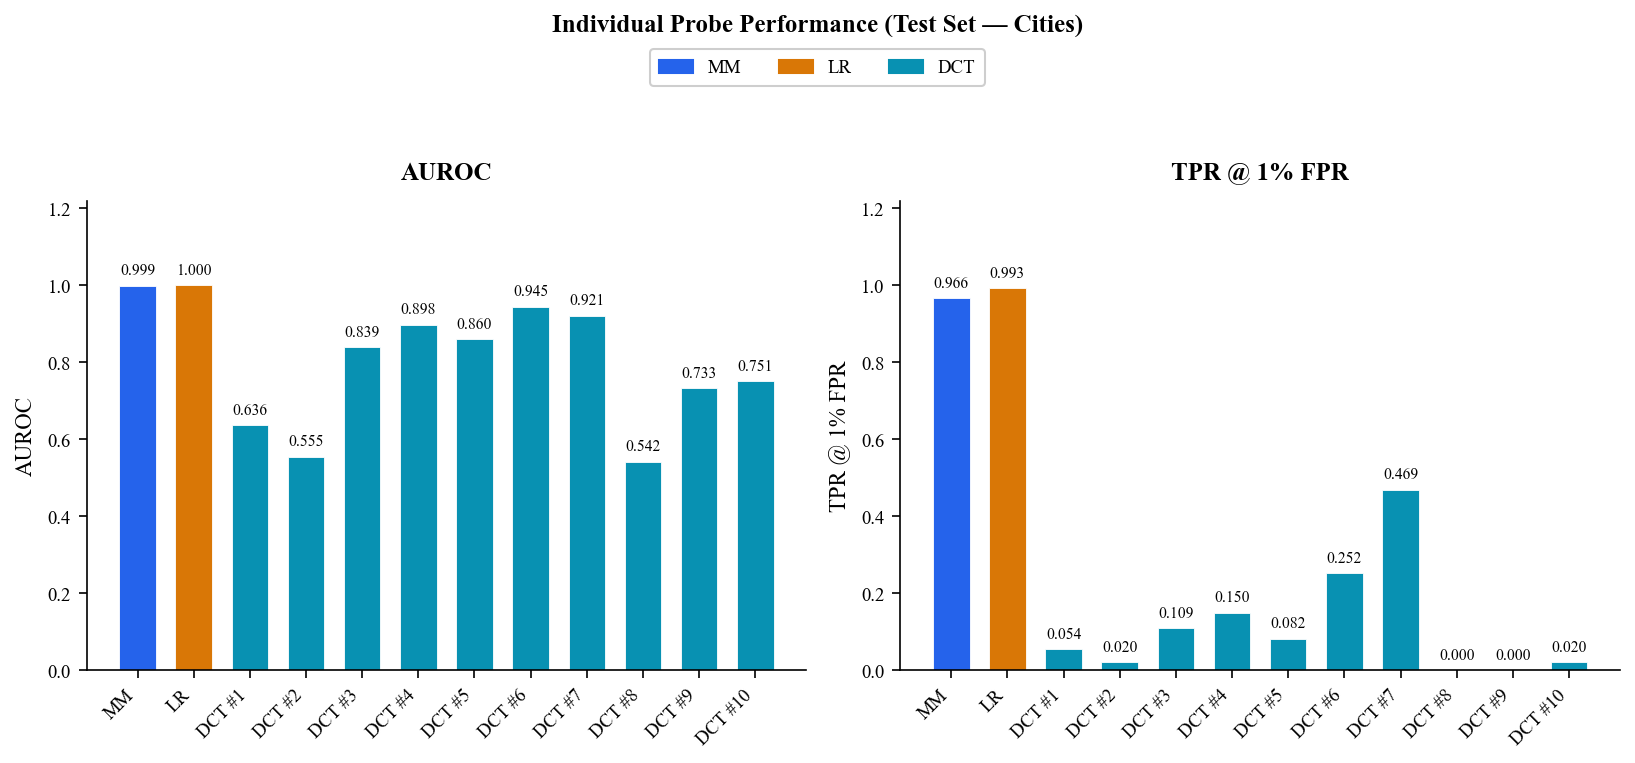

In [15]:
probe_names = list(results.keys())
aurocs = [results[n]["auroc"] for n in probe_names]
tprs   = [results[n]["tpr@1fpr"] for n in probe_names]
bar_colors = [
    COLORS["mm"] if n == "MM" else COLORS["lr"] if n == "LR" else COLORS["dct"]
    for n in probe_names
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, vals, ylabel in [(axes[0], aurocs, "AUROC"), (axes[1], tprs, "TPR @ 1% FPR")]:
    x = np.arange(len(probe_names))
    bars = ax.bar(x, vals, color=bar_colors, width=0.65, edgecolor="white", linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(probe_names, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.22)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2., val + 0.018,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7.5
        )
    ax.spines["bottom"].set_linewidth(0.8)

axes[0].set_title("AUROC", fontweight="bold")
axes[1].set_title("TPR @ 1% FPR", fontweight="bold")

legend_handles = [
    mpatches.Patch(color=COLORS["mm"],  label="MM"),
    mpatches.Patch(color=COLORS["lr"],  label="LR"),
    mpatches.Patch(color=COLORS["dct"], label="DCT"),
]
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 1.0),
           ncol=3, frameon=True, fontsize=9)

fig.suptitle("Individual Probe Performance (Test Set — Cities)", fontweight="bold", y=1.12)
fig.tight_layout()
save_fig(fig, "exp1_probe_performance")
plt.show()

Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp1_roc_curves.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp1_roc_curves.pdf


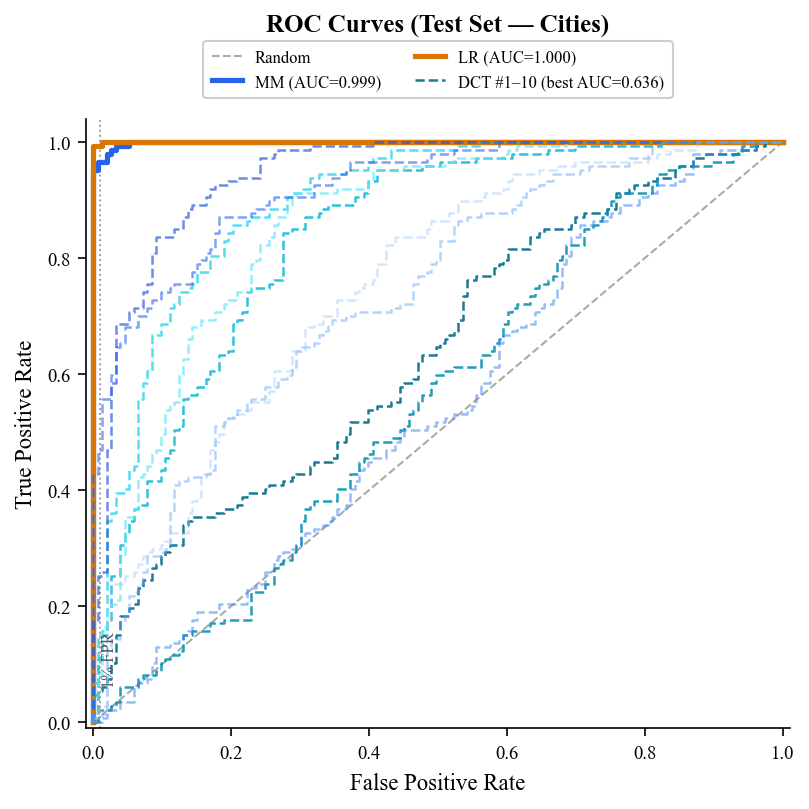

In [16]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.plot([0, 1], [0, 1], color="#AAAAAA", lw=1, ls="--", zorder=0, label="Random")
ax.axvline(x=0.01, color="#555555", ls=":", lw=0.9, alpha=0.6)
ax.text(0.013, 0.06, "1% FPR", fontsize=8, color="#555555", rotation=90, va="bottom")

r = results["MM"]
ax.plot(r["fpr"], r["tpr"], color=COLORS["mm"], lw=2.5, label=f"MM (AUC={r['auroc']:.3f})")
r = results["LR"]
ax.plot(r["fpr"], r["tpr"], color=COLORS["lr"], lw=2.5, label=f"LR (AUC={r['auroc']:.3f})")

for i, name in enumerate(list(dct_probes.keys())):
    r = results[name]
    alpha = max(0.35, 0.95 - 0.06 * i)
    label = f"DCT #1–10 (best AUC={results[list(dct_probes.keys())[0]]['auroc']:.3f})" if i == 0 else f"_{name}"
    ax.plot(r["fpr"], r["tpr"], color=DCT_COLORS[i % len(DCT_COLORS)], lw=1.2,
            alpha=alpha, ls="--", label=label)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (Test Set — Cities)", fontweight="bold", pad=42)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=2, frameon=True, fontsize=8)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.04)
fig.tight_layout()
save_fig(fig, "exp1_roc_curves")
plt.show()

## Experiment 2 — Generalization Across Datasets

In [17]:
TOP_K_GEN = 10

def best_dct_probe_for(acts, labels):
    candidates = all_indices_by_judge[:TOP_K_GEN]
    best_idx, best_auroc = -1, -1.0
    for idx in candidates:
        probe = DirectionalProbe(V[:, idx].float())
        train_probe(probe, acts, labels)
        auroc = eval_probe(probe, acts, labels)["auroc"]
        if auroc > best_auroc:
            best_auroc, best_idx = auroc, idx
    probe = DirectionalProbe(V[:, best_idx].float())
    train_probe(probe, acts, labels)
    return probe


def build_generalization_data(probe_factory, tr_acts, tr_labels, te_acts, te_labels, ds_names):
    gen = {}
    for train_name in ds_names:
        probe = probe_factory(tr_acts[train_name], tr_labels[train_name])
        gen[train_name] = {
            test_name: eval_probe(probe, te_acts[test_name], te_labels[test_name])
            for test_name in ds_names
        }
    return gen


gen_mm  = build_generalization_data(lambda a, l: MMProbe.from_data(a, l),  train_acts, train_labels, test_acts, test_labels, DATASET_NAMES)
gen_lr  = build_generalization_data(lambda a, l: LRProbe.from_data(a, l),  train_acts, train_labels, test_acts, test_labels, DATASET_NAMES)
gen_dct = build_generalization_data(best_dct_probe_for, train_acts, train_labels, test_acts, test_labels, DATASET_NAMES)
print("Generalization data computed.")

Generalization data computed.


Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp2_generalization_auroc.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp2_generalization_auroc.pdf


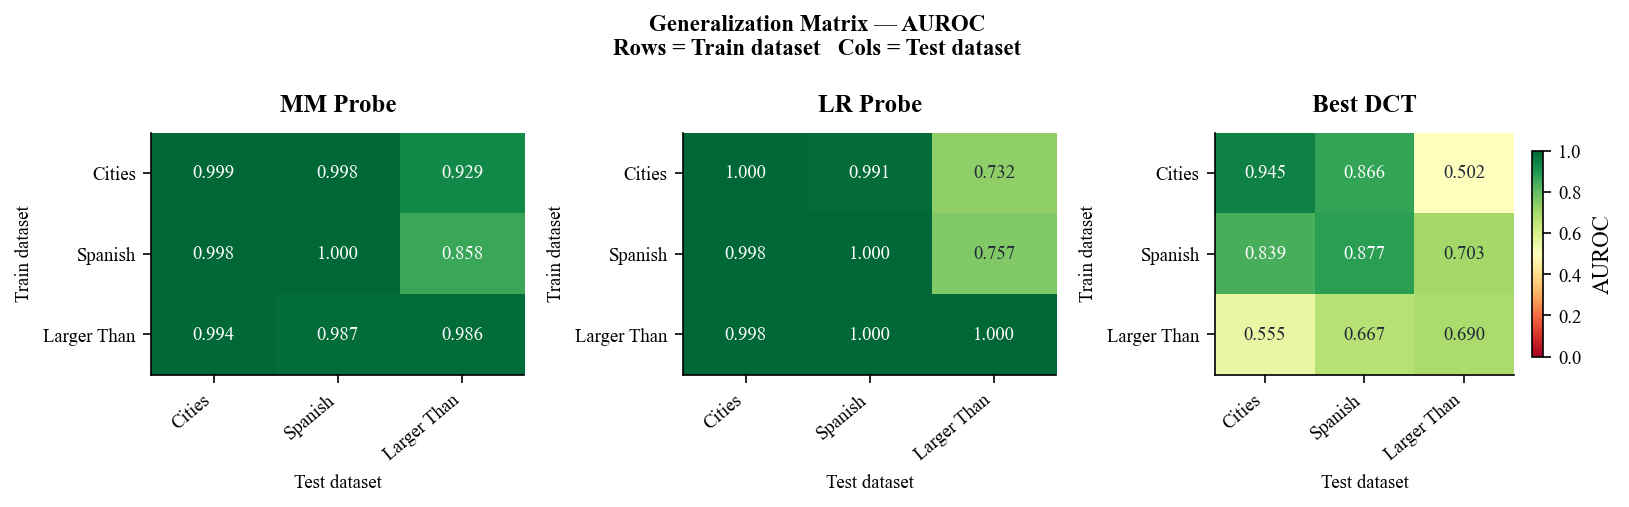

Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp2_generalization_tprat1fpr.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp2_generalization_tprat1fpr.pdf


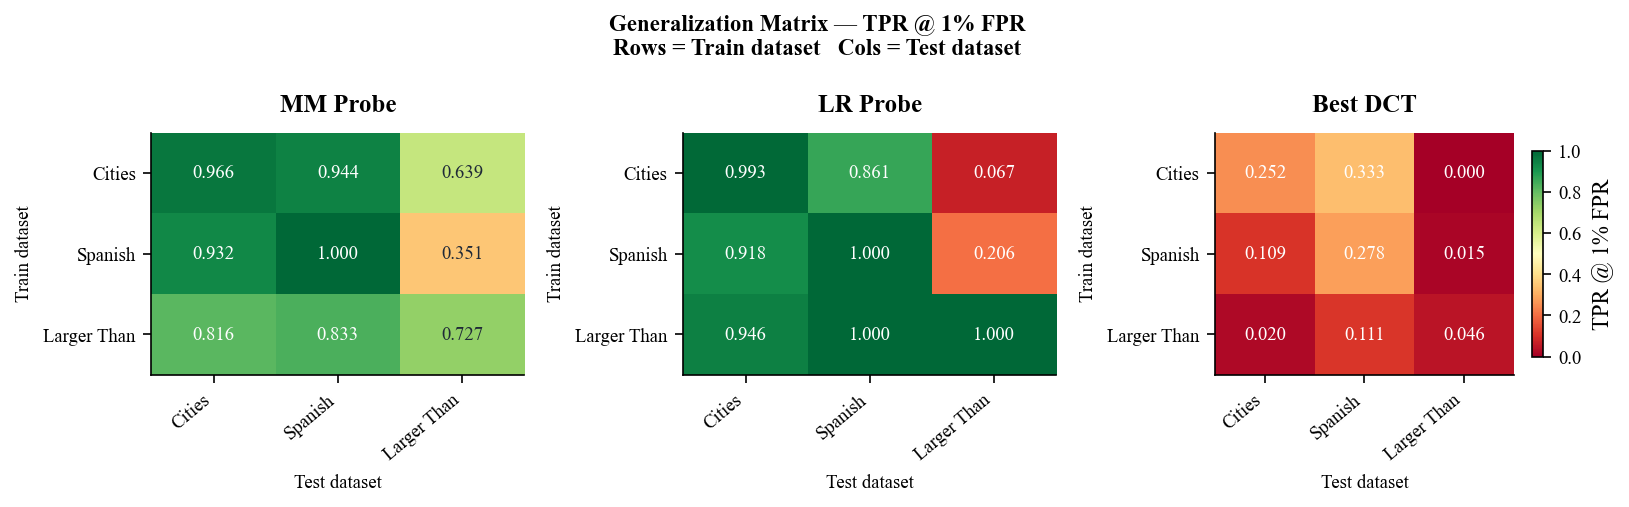

In [18]:
def gen_to_matrix(gen_data, metric, ds_names):
    mat = np.zeros((len(ds_names), len(ds_names)))
    for i, tn in enumerate(ds_names):
        for j, en in enumerate(ds_names):
            mat[i, j] = gen_data[tn][en][metric]
    return mat


labels_display = [DATASET_DISPLAY[n] for n in DATASET_NAMES]

for metric, metric_title in [("auroc", "AUROC"), ("tpr@1fpr", "TPR @ 1% FPR")]:
    matrices = [
        gen_to_matrix(gen_mm,  metric, DATASET_NAMES),
        gen_to_matrix(gen_lr,  metric, DATASET_NAMES),
        gen_to_matrix(gen_dct, metric, DATASET_NAMES),
    ]
    titles = ["MM Probe", "LR Probe", "Best DCT"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(DATASET_NAMES)))
        ax.set_yticks(range(len(DATASET_NAMES)))
        ax.set_xticklabels(labels_display, rotation=40, ha="right")
        ax.set_yticklabels(labels_display)
        ax.set_xlabel("Test dataset", fontsize=9)
        ax.set_ylabel("Train dataset", fontsize=9)
        ax.set_title(title, fontweight="bold")
        for i in range(len(DATASET_NAMES)):
            for j in range(len(DATASET_NAMES)):
                v = mat[i, j]
                color = "white" if v < 0.35 or v > 0.8 else "#1F2937"
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=9, color=color)

    plt.colorbar(im, ax=axes[-1], label=metric_title, shrink=0.85)
    fig.suptitle(f"Generalization Matrix — {metric_title}\n"
                 "Rows = Train dataset   Cols = Test dataset",
                 fontweight="bold", fontsize=11)
    fig.tight_layout()
    metric_slug = metric.replace("@", "at").replace("%", "pct").replace(" ", "_")
    save_fig(fig, f"exp2_generalization_{metric_slug}")
    plt.show()

## Experiment 3 — Ensemble k-sweep

In [19]:
K_VALUES = [k for k in [1, 2, 3, 5, 8, 10, 15, 20, 30, 50] if k <= V.shape[1]]

sweep = {"k": K_VALUES}
for key in ["mean_train_auroc", "mean_test_auroc", "mean_train_tpr1", "mean_test_tpr1",
            "max_train_auroc",  "max_test_auroc",  "max_train_tpr1",  "max_test_tpr1"]:
    sweep[key] = []

for k in tqdm(K_VALUES, desc="k-sweep"):
    top_idx = all_indices_by_judge[:k]
    directions = V[:, top_idx].float()
    for agg in ["mean", "max"]:
        probe = FixedEnsembleProbe(directions, aggregation=agg)
        train_probe(probe, train_acts["cities"], train_labels["cities"])
        tr = eval_probe(probe, train_acts["cities"], train_labels["cities"])
        te = eval_probe(probe, test_acts["cities"],  test_labels["cities"])
        sweep[f"{agg}_train_auroc"].append(tr["auroc"])
        sweep[f"{agg}_test_auroc"].append(te["auroc"])
        sweep[f"{agg}_train_tpr1"].append(tr["tpr@1fpr"])
        sweep[f"{agg}_test_tpr1"].append(te["tpr@1fpr"])

sweep_df = pd.DataFrame({
    "k": sweep["k"],
    "Mean Test AUROC": [f"{v:.3f}" for v in sweep["mean_test_auroc"]],
    "Max Test AUROC":  [f"{v:.3f}" for v in sweep["max_test_auroc"]],
})
display(sweep_df)

k-sweep:   0%|          | 0/10 [00:00<?, ?it/s]

k-sweep: 100%|██████████| 10/10 [00:06<00:00,  1.60it/s]


,k,Mean Test AUROC,Max Test AUROC
0,1,0.636,0.636
1,2,0.633,0.636
2,3,0.821,0.636
3,5,0.958,0.636
4,8,0.971,0.636
5,10,0.955,0.636
6,15,0.956,0.636
7,20,0.953,0.636
8,30,0.951,0.636
9,50,0.942,0.759


Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp3_ensemble_sweep_auroc.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp3_ensemble_sweep_auroc.pdf


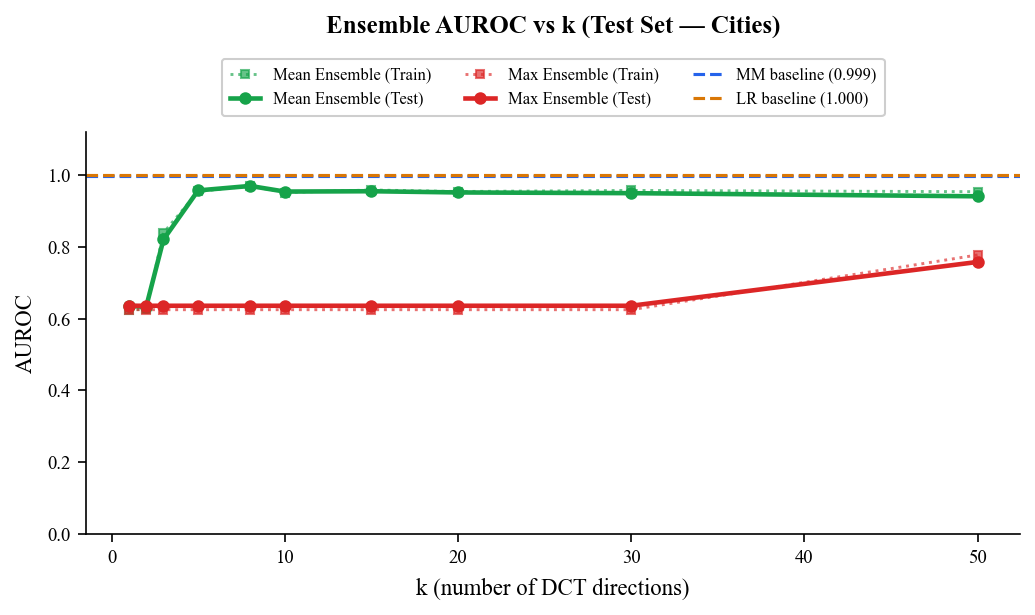

Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp3_ensemble_sweep_tpr1.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp3_ensemble_sweep_tpr1.pdf


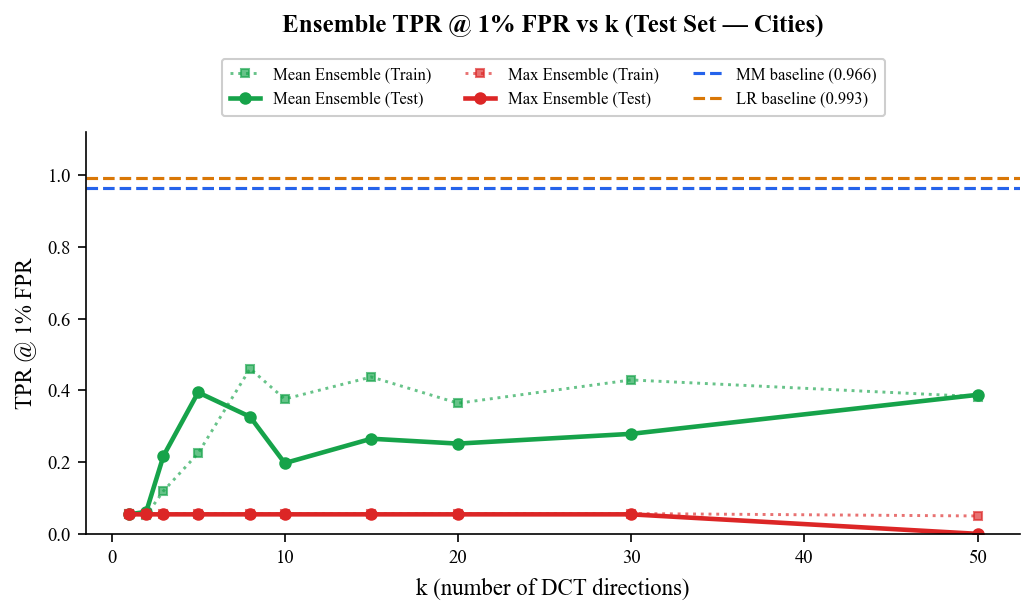

Best k (Mean Ensemble): k=8  (0.971)
Best k (Max Ensemble):  k=50  (0.759)


In [20]:
mm_test_cities = eval_probe(mm_probe, test_acts["cities"], test_labels["cities"])
lr_test_cities = eval_probe(lr_probe, test_acts["cities"], test_labels["cities"])

for metric_key, metric_title in [("auroc", "AUROC"), ("tpr1", "TPR @ 1% FPR")]:
    baseline_metric = "auroc" if metric_key == "auroc" else "tpr@1fpr"
    mm_val = mm_test_cities[baseline_metric]
    lr_val = lr_test_cities[baseline_metric]

    fig, ax = plt.subplots(figsize=(7, 4.2))

    for agg, color, label in [
        ("mean", COLORS["ensemble_mean"], "Mean Ensemble"),
        ("max",  COLORS["ensemble_max"],  "Max Ensemble"),
    ]:
        ax.plot(sweep["k"], sweep[f"{agg}_train_{metric_key}"],
                color=color, lw=1.4, ls=":", marker="s", markersize=4,
                label=f"{label} (Train)", alpha=0.65)
        ax.plot(sweep["k"], sweep[f"{agg}_test_{metric_key}"],
                color=color, lw=2.2, marker="o", markersize=5,
                label=f"{label} (Test)")

    ax.axhline(y=mm_val, color=COLORS["mm"], ls="--", lw=1.5, label=f"MM baseline ({mm_val:.3f})")
    ax.axhline(y=lr_val, color=COLORS["lr"], ls="--", lw=1.5, label=f"LR baseline ({lr_val:.3f})")

    ax.set_xlabel("k (number of DCT directions)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Ensemble {metric_title} vs k (Test Set — Cities)", fontweight="bold", pad=48)
    ax.set_ylim(0, 1.12)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02),
              ncol=3, frameon=True, fontsize=8)
    fig.tight_layout()
    save_fig(fig, f"exp3_ensemble_sweep_{metric_key}")
    plt.show()

best_k_mean = K_VALUES[int(np.argmax(sweep["mean_test_auroc"]))]
best_k_max  = K_VALUES[int(np.argmax(sweep["max_test_auroc"]))]
print(f"Best k (Mean Ensemble): k={best_k_mean}  ({max(sweep['mean_test_auroc']):.3f})")
print(f"Best k (Max Ensemble):  k={best_k_max}  ({max(sweep['max_test_auroc']):.3f})")

## Experiment 4 — Ensemble Generalization

In [21]:
best_k = best_k_mean
top_idx_best = all_indices_by_judge[:best_k]
directions_best = V[:, top_idx_best].float()
print(f"Using k={best_k}")

def make_ens_probe(agg):
    def factory(acts, labels):
        probe = FixedEnsembleProbe(directions_best, aggregation=agg)
        train_probe(probe, acts, labels)
        return probe
    return factory

gen_ens_mean = build_generalization_data(make_ens_probe("mean"), train_acts, train_labels, test_acts, test_labels, DATASET_NAMES)
gen_ens_max  = build_generalization_data(make_ens_probe("max"),  train_acts, train_labels, test_acts, test_labels, DATASET_NAMES)
print("Ensemble generalization computed.")

Using k=8
Ensemble generalization computed.


Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp4_ensemble_generalization_auroc.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp4_ensemble_generalization_auroc.pdf


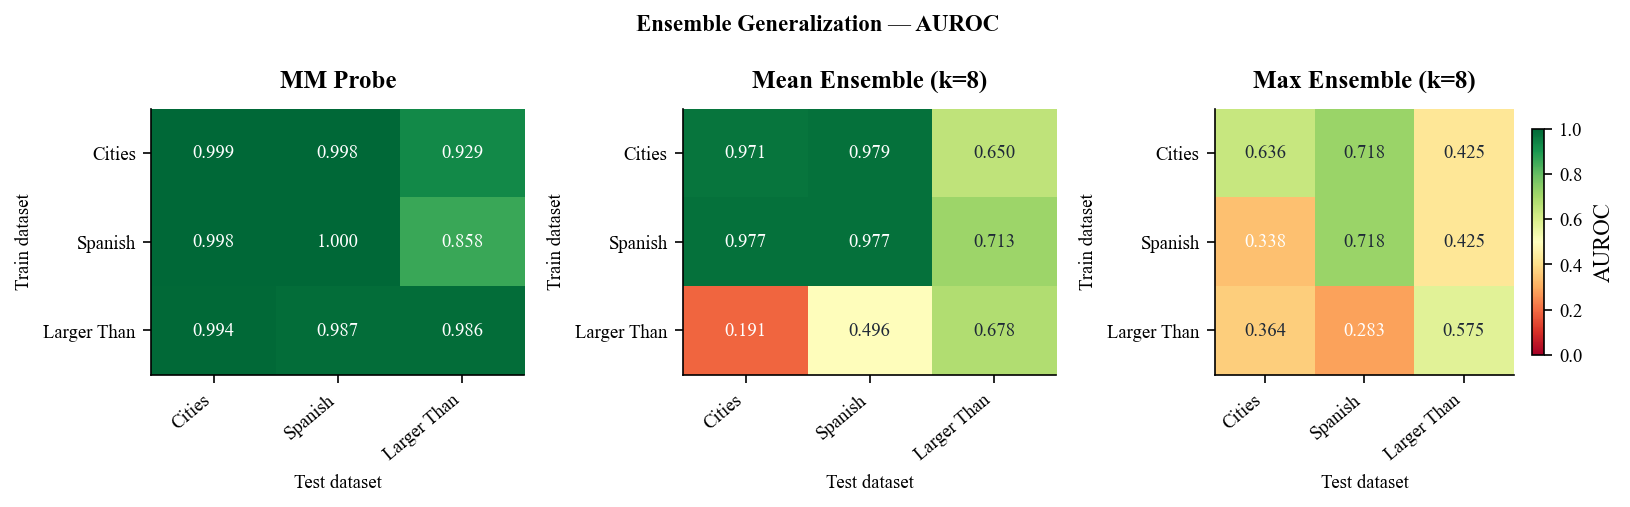

Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp4_ensemble_generalization_tprat1fpr.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp4_ensemble_generalization_tprat1fpr.pdf


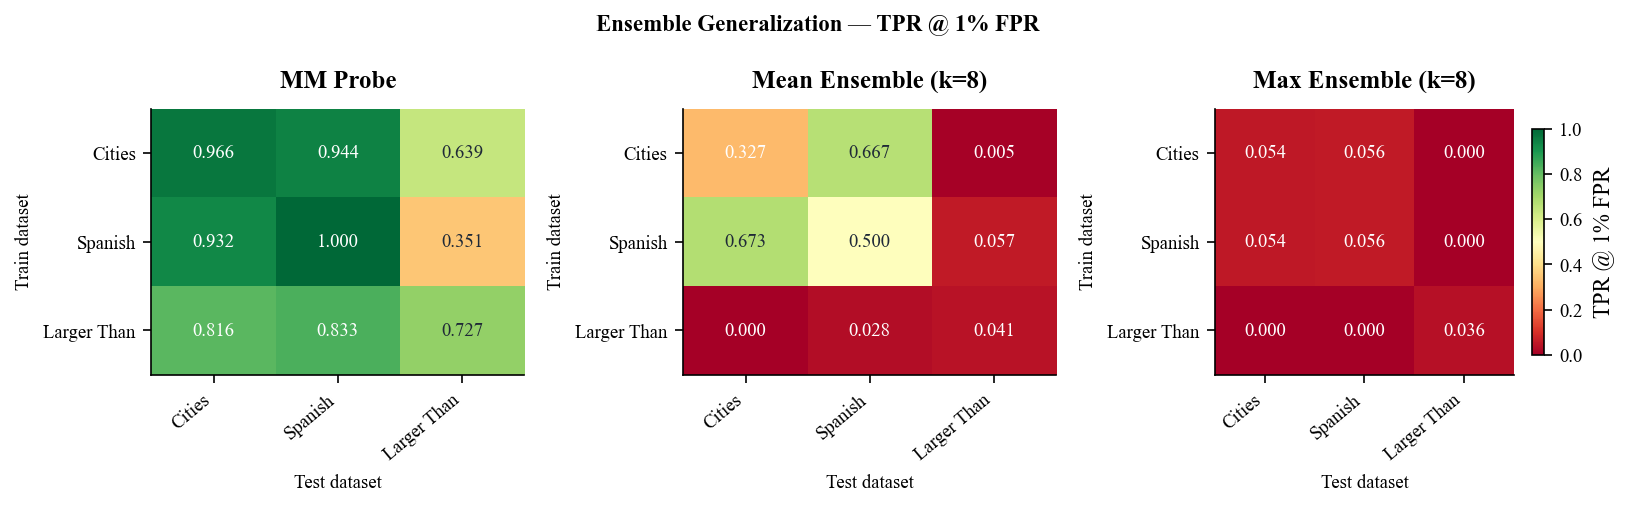

In [22]:
for metric, metric_title in [("auroc", "AUROC"), ("tpr@1fpr", "TPR @ 1% FPR")]:
    matrices = [
        gen_to_matrix(gen_mm,       metric, DATASET_NAMES),
        gen_to_matrix(gen_ens_mean, metric, DATASET_NAMES),
        gen_to_matrix(gen_ens_max,  metric, DATASET_NAMES),
    ]
    titles = ["MM Probe", f"Mean Ensemble (k={best_k})", f"Max Ensemble (k={best_k})"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(DATASET_NAMES)))
        ax.set_yticks(range(len(DATASET_NAMES)))
        ax.set_xticklabels(labels_display, rotation=40, ha="right")
        ax.set_yticklabels(labels_display)
        ax.set_xlabel("Test dataset", fontsize=9)
        ax.set_ylabel("Train dataset", fontsize=9)
        ax.set_title(title, fontweight="bold")
        for i in range(len(DATASET_NAMES)):
            for j in range(len(DATASET_NAMES)):
                v = mat[i, j]
                color = "white" if v < 0.35 or v > 0.8 else "#1F2937"
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=9, color=color)

    plt.colorbar(im, ax=axes[-1], label=metric_title, shrink=0.85)
    fig.suptitle(f"Ensemble Generalization — {metric_title}", fontweight="bold", fontsize=11)
    fig.tight_layout()
    metric_slug = metric.replace("@", "at").replace("%", "pct").replace(" ", "_")
    save_fig(fig, f"exp4_ensemble_generalization_{metric_slug}")
    plt.show()

## Experiment 5 — DCT vs Random Subspace

In [23]:
N_RANDOM_TRIALS = 20
K_VALUES_EXP5 = [k for k in [1, 2, 3, 5, 8, 10, 15, 20, 30, 50] if k <= V.shape[1]]

train_a = train_acts["cities"]
train_l = train_labels["cities"]
test_a  = test_acts["cities"]
test_l  = test_labels["cities"]
d_model = train_a.shape[1]


def subspace_lr_auroc(train_proj, test_proj, tr_l, te_l):
    scaler = StandardScaler()
    train_proj = scaler.fit_transform(train_proj)
    test_proj  = scaler.transform(test_proj)
    lr = LogisticRegression(max_iter=1000)
    lr.fit(train_proj, tr_l.numpy())
    scores = lr.predict_proba(test_proj)[:, 1]
    return roc_auc_score(te_l.numpy(), scores)


dct_aurocs = []
for k in K_VALUES_EXP5:
    top_idx = all_indices_by_judge[:k]
    Q, _ = torch.linalg.qr(V[:, top_idx].float())
    dct_aurocs.append(subspace_lr_auroc(
        (train_a.float() @ Q).detach().numpy(), (test_a.float() @ Q).detach().numpy(), train_l, test_l
    ))

random_aurocs_by_trial = []
for _ in tqdm(range(N_RANDOM_TRIALS), desc="random trials"):
    trial = []
    for k in K_VALUES_EXP5:
        Q, _ = torch.linalg.qr(torch.randn(d_model, k))
        trial.append(subspace_lr_auroc(
            (train_a.float() @ Q).detach().numpy(), (test_a.float() @ Q).detach().numpy(), train_l, test_l
        ))
    random_aurocs_by_trial.append(trial)
random_mean = np.mean(random_aurocs_by_trial, axis=0)

scaler_full = StandardScaler()
lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(scaler_full.fit_transform(train_a.numpy()), train_l.numpy())
full_scores = lr_full.predict_proba(scaler_full.transform(test_a.numpy()))[:, 1]
full_auroc = roc_auc_score(test_l.numpy(), full_scores)
print(f"Full-space LR AUROC: {full_auroc:.3f}")

random trials: 100%|██████████| 20/20 [00:00<00:00, 36.60it/s]

Full-space LR AUROC: 1.000


Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp5_dct_vs_random_subspace.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp5_dct_vs_random_subspace.pdf


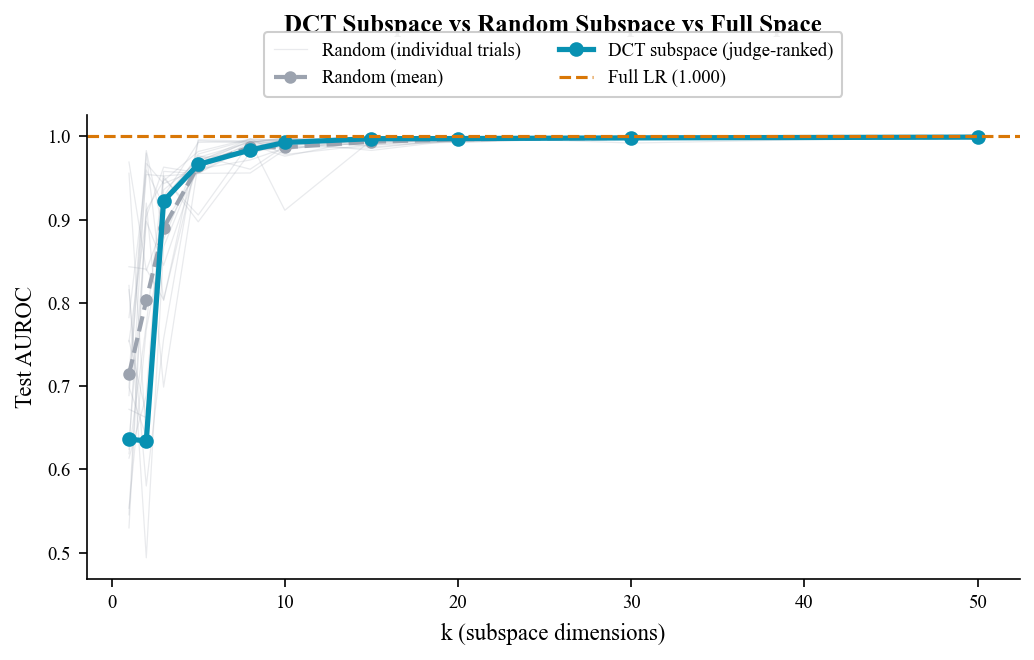

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for i, trial in enumerate(random_aurocs_by_trial):
    ax.plot(K_VALUES_EXP5, trial, color=COLORS["random"], lw=0.6, alpha=0.22,
            label="Random (individual trials)" if i == 0 else "_nolegend_")

ax.plot(K_VALUES_EXP5, random_mean, color=COLORS["random"], lw=2, ls="--",
        marker="o", markersize=5, label="Random (mean)")

ax.plot(K_VALUES_EXP5, dct_aurocs, color=COLORS["dct"], lw=2.5,
        marker="o", markersize=6, label="DCT subspace (judge-ranked)")

ax.axhline(y=full_auroc, color=COLORS["lr"], ls="--", lw=1.5,
           label=f"Full LR ({full_auroc:.3f})")

ax.set_xlabel("k (subspace dimensions)")
ax.set_ylabel("Test AUROC")
ax.set_title("DCT Subspace vs Random Subspace vs Full Space", fontweight="bold", pad=40)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=2, frameon=True, fontsize=9)
fig.tight_layout()
save_fig(fig, "exp5_dct_vs_random_subspace")
plt.show()

## Experiment 6 — Judge Score vs Probe Quality

In [25]:
all_factor_metrics = []
for idx in tqdm(range(V.shape[1]), desc="per-factor eval"):
    probe = DirectionalProbe(V[:, idx].float())
    train_probe(probe, train_acts["cities"], train_labels["cities"])
    r = eval_probe(probe, test_acts["cities"], test_labels["cities"])
    judge_score = float(mean_deltas[idx]) if idx in mean_deltas.index else float("nan")
    all_factor_metrics.append({
        "factor_idx": idx,
        "judge_score": judge_score,
        "auroc": r["auroc"],
        "tpr@1fpr": r["tpr@1fpr"],
    })

df_factors = pd.DataFrame(all_factor_metrics).dropna(subset=["judge_score"])

rho_auroc, p_auroc = scipy_stats.spearmanr(df_factors["judge_score"], df_factors["auroc"])
rho_tpr,   p_tpr   = scipy_stats.spearmanr(df_factors["judge_score"], df_factors["tpr@1fpr"])

print(f"Spearman rho (judge vs AUROC):     {rho_auroc:+.3f}  p={p_auroc:.4f}")
print(f"Spearman rho (judge vs TPR@1%FPR): {rho_tpr:+.3f}  p={p_tpr:.4f}")

per-factor eval: 100%|██████████| 1024/1024 [02:51<00:00,  5.95it/s]

Spearman rho (judge vs AUROC):     +0.079  p=0.0117
Spearman rho (judge vs TPR@1%FPR): +0.066  p=0.0358


Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp6_judge_score_vs_probe_quality.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/exp6_judge_score_vs_probe_quality.pdf


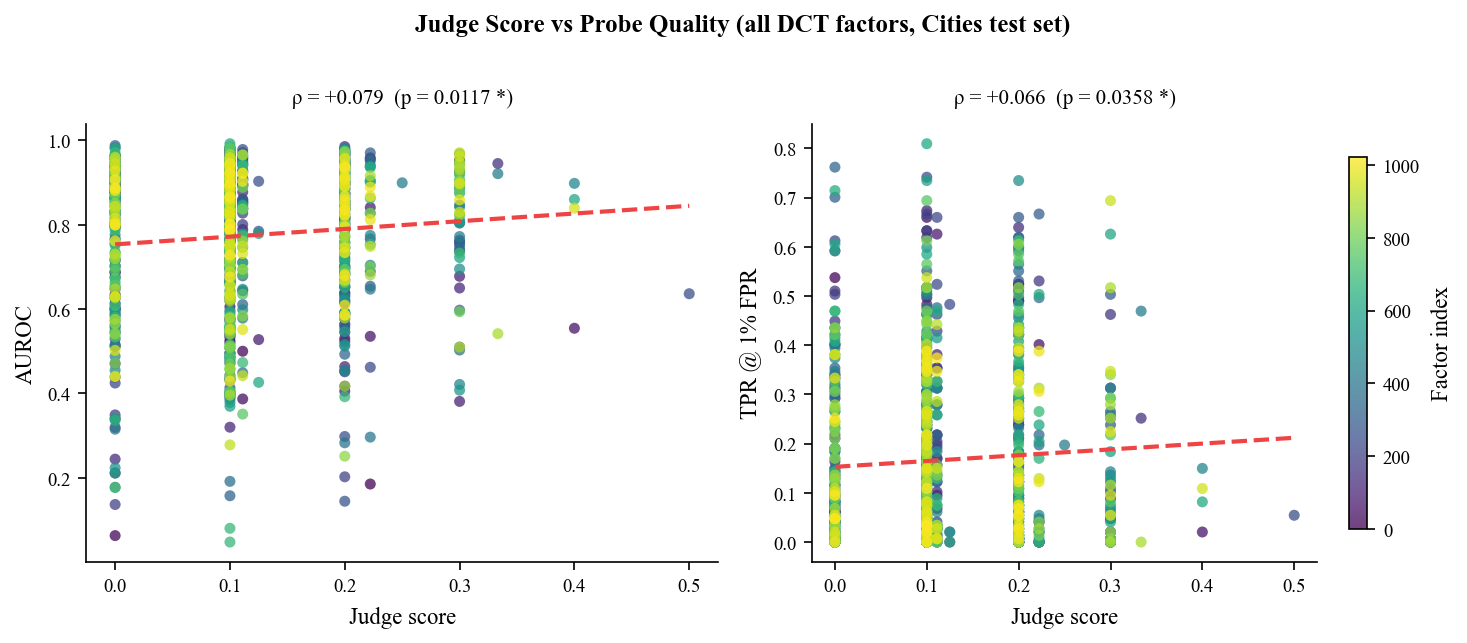

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

for ax, metric, ylabel, rho, p_val in [
    (axes[0], "auroc",    "AUROC",         rho_auroc, p_auroc),
    (axes[1], "tpr@1fpr", "TPR @ 1% FPR", rho_tpr,   p_tpr),
]:
    x = df_factors["judge_score"].values
    y = df_factors[metric].values

    sc = ax.scatter(x, y, c=df_factors["factor_idx"], cmap="viridis",
                    s=28, alpha=0.75, edgecolors="none")

    slope, intercept, *_ = scipy_stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="#EF4444", lw=2, ls="--")

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    ax.set_title(f"\u03c1 = {rho:+.3f}  (p = {p_val:.4f} {sig})", fontsize=10)
    ax.set_xlabel("Judge score")
    ax.set_ylabel(ylabel)

plt.colorbar(sc, ax=axes[1], label="Factor index", shrink=0.85)
fig.suptitle("Judge Score vs Probe Quality (all DCT factors, Cities test set)",
             fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "exp6_judge_score_vs_probe_quality")
plt.show()

## Cross-run Comparison — Top-32 Factors: 10-Prompt vs 40-Prompt Judging

The 10-prompt run (`llama-3.1-8b-1024factors-categorical`) evaluated all 1024 DCT factors on 10 prompts.
The 40-prompt run (`llama-3.1-8b-1024factors-40prompts-categorical`) re-evaluated the top 32 of those factors on 40 prompts.

The butterfly chart below shows each factor's full response-category distribution under both judging conditions,
sorted by its Confidently Wrong rate on 10 prompts, with Confidently Wrong anchored at the centre axis.

In [27]:
from collections import defaultdict

EXP_10 = "llama-3.1-8b-1024factors-categorical"
EXP_40 = "llama-3.1-8b-1024factors-40prompts-categorical"
base_dir = Path("dct_probes/experiments")

# Load both V matrices and map V40 columns → V10 columns by exact L2 match
V_10 = torch.load(base_dir / EXP_10 / "vectors" / "dct_vectors.pt",
                  weights_only=True, map_location="cpu")["V"].float()
V_40 = torch.load(base_dir / EXP_40 / "vectors" / "dct_vectors.pt",
                  weights_only=True, map_location="cpu")["V"].float()

v40_to_v10 = {}
for i in range(V_40.shape[1]):
    diffs = (V_10 - V_40[:, i:i+1]).norm(dim=0)
    v40_to_v10[i] = int(diffs.argmin().item())
print(f"Mapped {len(v40_to_v10)} V40 columns → V10 columns (all exact matches)")

# Category constants
CMP_CATS   = ["CONFIDENTLY_WRONG", "HEDGED_WRONG", "CORRECT", "GARBAGE", "REFUSAL"]
CMP_COLORS = {
    "CONFIDENTLY_WRONG": "#B91C1C",
    "HEDGED_WRONG":      "#F87171",
    "CORRECT":           "#16A34A",
    "GARBAGE":           "#9CA3AF",
    "REFUSAL":           "#374151",
}

def load_dist(exp_name):
    """Return {factor_idx: {category: proportion}} from judge_results.jsonl."""
    path = base_dir / exp_name / "results" / "judge_results.jsonl"
    cats_by_factor = defaultdict(list)
    baseline_cats = []
    for line in open(path):
        r = json.loads(line)
        if r.get("factor_idx", -1) >= 0:
            cats_by_factor[r["factor_idx"]].append(r.get("judge_category", ""))
        elif r.get("factor_idx") == -1:
            baseline_cats.append(r.get("judge_category", ""))
    dist = {}
    for idx, cats in cats_by_factor.items():
        n = len(cats)
        dist[idx] = {c: sum(x == c for x in cats) / n for c in CMP_CATS}
    if baseline_cats:
        n = len(baseline_cats)
        dist[-1] = {c: sum(x == c for x in baseline_cats) / n for c in CMP_CATS}
    return dist

dist_10 = load_dist(EXP_10)
dist_40 = load_dist(EXP_40)

# Build the 32-factor comparison list, sorted by CW on 10 prompts (highest first)
shared = []
for i40, i10 in v40_to_v10.items():
    if i10 in dist_10 and i40 in dist_40:
        shared.append({
            "v10_idx": i10,
            "v40_idx": i40,
            "dist_10": dist_10[i10],
            "dist_40": dist_40[i40],
        })
shared.sort(key=lambda x: x["dist_10"].get("CONFIDENTLY_WRONG", 0), reverse=True)
for rank, f in enumerate(shared):
    f["rank"] = rank + 1

print(f"Factors in comparison: {len(shared)}")
print("Top 5 by CW (10 prompts):")
for f in shared[:5]:
    print(f"  Rank {f['rank']}  V10-idx={f['v10_idx']:>4d}  "
          f"CW_10={f['dist_10']['CONFIDENTLY_WRONG']:.2f}  "
          f"CW_40={f['dist_40']['CONFIDENTLY_WRONG']:.2f}")

Mapped 32 V40 columns → V10 columns (all exact matches)
Factors in comparison: 32
Top 5 by CW (10 prompts):
  Rank 1  V10-idx= 246  CW_10=0.50  CW_40=0.15
  Rank 2  V10-idx= 472  CW_10=0.40  CW_40=0.07
  Rank 3  V10-idx= 953  CW_10=0.40  CW_40=0.10
  Rank 4  V10-idx=  59  CW_10=0.40  CW_40=0.05
  Rank 5  V10-idx= 619  CW_10=0.40  CW_40=0.07


Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/comparison_butterfly_10_vs_40_prompts.svg
Saved: dct_probes/images/llama-3.1-8b-1024factors-categorical/pub/comparison_butterfly_10_vs_40_prompts.pdf


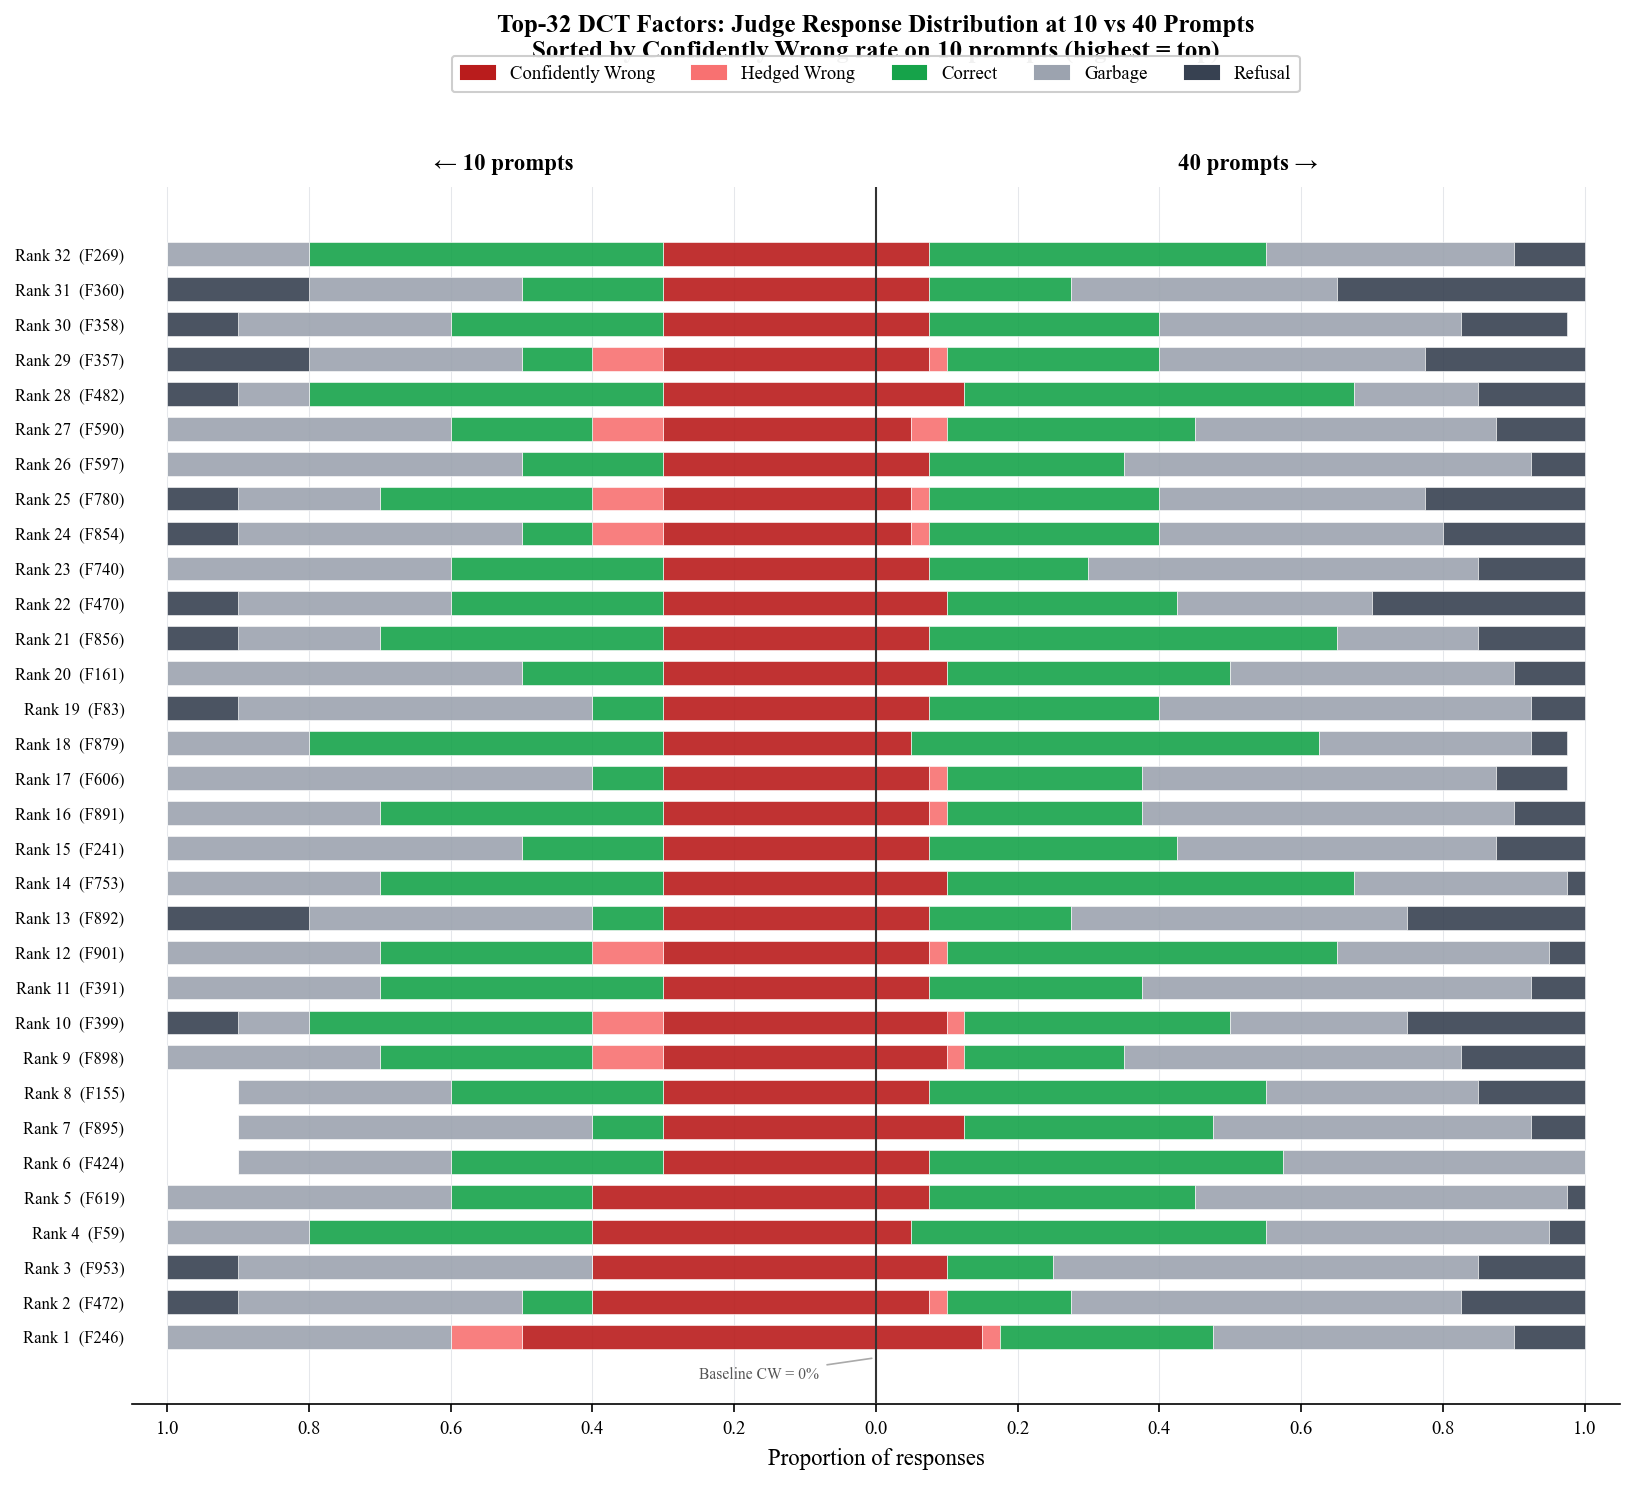

In [28]:
n = len(shared)
y = np.arange(n)
y_labels = [f"Rank {f['rank']}  (F{f['v10_idx']})" for f in shared]

# Stack order: CW anchored at centre, then outward
stack_order = ["CONFIDENTLY_WRONG", "HEDGED_WRONG", "CORRECT", "GARBAGE", "REFUSAL"]

fig, ax = plt.subplots(figsize=(11, 10))

lefts_left  = np.zeros(n)
lefts_right = np.zeros(n)

for cat in stack_order:
    vals_10 = np.array([f["dist_10"].get(cat, 0) for f in shared])
    vals_40 = np.array([f["dist_40"].get(cat, 0) for f in shared])
    color = CMP_COLORS[cat]
    ax.barh(y, -vals_10, left=-lefts_left,  color=color, height=0.68,
            edgecolor="white", linewidth=0.3, alpha=0.9)
    ax.barh(y,  vals_40, left= lefts_right, color=color, height=0.68,
            edgecolor="white", linewidth=0.3, alpha=0.9)
    lefts_left  += vals_10
    lefts_right += vals_40

# Centre axis
ax.axvline(0, color="#333333", lw=1.0, zorder=5)

# Side headers — use axes transform so y=1 is the top edge of the plot
ax.text(0.25, 1.01, "← 10 prompts", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)
ax.text(0.75, 1.01, "40 prompts →", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)

# Y-axis
ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=8)
ax.yaxis.set_tick_params(length=0)

# X-axis
ax.set_xlim(-1.05, 1.05)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{abs(v):.1f}"))
ax.set_xlabel("Proportion of responses")

# Light vertical grid
for xv in np.arange(-1.0, 1.01, 0.2):
    ax.axvline(xv, color="#E5E7EB", lw=0.5, zorder=0)

# Baseline annotation
if -1 in dist_10:
    cw = dist_10[-1].get("CONFIDENTLY_WRONG", 0)
    ax.annotate(f"Baseline CW = {cw:.0%}", xy=(-cw, -0.6), xytext=(-cw - 0.25, -1.2),
                fontsize=7.5, color="#555555",
                arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.8))

ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)

# Legend above chart (sits above the side headers)
legend_handles = [
    mpatches.Patch(color=CMP_COLORS[c], label=c.replace("_", " ").title())
    for c in stack_order
]
ax.legend(handles=legend_handles,
          loc="lower center", bbox_to_anchor=(0.5, 1.07),
          ncol=5, frameon=True, fontsize=9)

ax.set_title(
    "Top-32 DCT Factors: Judge Response Distribution at 10 vs 40 Prompts\n"
    "Sorted by Confidently Wrong rate on 10 prompts (highest = top)",
    fontweight="bold", pad=62,
)

fig.tight_layout()
save_fig(fig, "comparison_butterfly_10_vs_40_prompts")
plt.show()